In [1]:
# ======================================
# 04 Strategy Backtest + Cohort Analysis
# ======================================
#
# Purpose:
# --------
# Notebook 03 trained the model and exported scored predictions.
#
# This notebook evaluates how those predictions behave when translated
# into portfolio strategies.
#
# We are no longer using "low / medium / high" risk buckets.
# Instead, we test two strategy families:
#
# 1. Core Alpha:
#    Diversified rank-weighted basket intended to beat SPY consistently.
#
# 2. Convex Alpha:
#    Concentrated high-conviction basket intended to capture power-law winners.
#
# Key question:
# -------------
# When does the model's edge appear?
# 1 month? 3 months? 6 months? 12 months? 24 months? 36 months?

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Paths ----
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

PRICE_FILE = RAW_DIR / "prices.parquet"
SCORED_TEST_FILE = PROCESSED_DIR / "scored_test_v4.parquet"

# ---- Load data ----
prices = pd.read_parquet(PRICE_FILE)
signals = pd.read_parquet(SCORED_TEST_FILE)

# ---- Date handling ----
prices["date"] = pd.to_datetime(prices["date"])
signals["date"] = pd.to_datetime(signals["date"])

prices["year_month"] = prices["date"].dt.to_period("M")
signals["year_month"] = signals["date"].dt.to_period("M")

# ---- Sort ----
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)
signals = signals.sort_values(["date", "ticker"]).reset_index(drop=True)

print("Prices shape:", prices.shape)
print("Signals shape:", signals.shape)

print("\nSignals columns:")
print(signals.columns.tolist())

signals.head()

Prices shape: (1903828, 9)
Signals shape: (11113, 14)

Signals columns:
['date', 'year_month', 'ticker', 'sector', 'predicted_target', 'predicted_excess_return', 'calibrated_pred', 'pred_rank', 'pred_bucket', 'fwd_3y_stock_return', 'fwd_3y_benchmark_return', 'excess_fwd_3y_return', 'target', 'delta']


,date,year_month,ticker,sector,predicted_target,predicted_excess_return,calibrated_pred,pred_rank,pred_bucket,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,target,delta
0,2021-01-29,2021-01,A,Healthcare,0.090295,0.094497,0.013015,4305.0,1,0.128636,0.381954,-0.253318,-0.225794,0.266333
1,2021-01-29,2021-01,AAPL,Technology,0.154253,0.166786,0.128240,7598.0,3,0.441044,0.381954,0.059090,0.057410,0.069151
2,2021-01-29,2021-01,ABBV,Healthcare,0.119303,0.126711,0.087501,4893.0,2,0.848563,0.381954,0.466609,0.382953,-0.379108
3,2021-01-29,2021-01,ABT,Healthcare,0.135824,0.145480,0.087501,4892.0,2,-0.023613,0.381954,-0.405567,-0.340441,0.493067
4,2021-01-29,2021-01,ACGL,Financial Services,0.187583,0.206330,0.275222,8802.0,3,1.613499,0.381954,1.231545,0.802694,-0.956323


In [2]:
# ======================================
# Monthly Stock Prices
# ======================================
#
# We evaluate portfolio selections at monthly horizons.
# For each ticker and month, we use the final available trading day.
#
# Result:
# ticker | year_month | month-end adjusted close

stock_monthly = (
    prices.sort_values("date")
    .groupby(["ticker", "year_month"])
    .tail(1)
    .reset_index(drop=True)
)

stock_monthly = stock_monthly[
    ["date", "year_month", "ticker", "adj_close"]
].copy()

stock_monthly = stock_monthly.sort_values(
    ["ticker", "year_month"]
).reset_index(drop=True)

print("Monthly stock prices shape:", stock_monthly.shape)
stock_monthly.head()

Monthly stock prices shape: (90875, 4)


,date,year_month,ticker,adj_close
0,2010-01-29,2010-01,A,17.741282
1,2010-02-26,2010-02,A,19.912256
2,2010-03-31,2010-03,A,21.766766
3,2010-04-30,2010-04,A,22.950361
4,2010-05-28,2010-05,A,20.481892


In [3]:
# ======================================
# Monthly Benchmark Prices
# ======================================
#
# We need SPY monthly prices to compare each selected cohort
# against the market over identical holding windows.

import yfinance as yf

BENCHMARK_TICKER = "SPY"

START_DATE = prices["date"].min().strftime("%Y-%m-%d")
END_DATE = (prices["date"].max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

benchmark = yf.download(
    BENCHMARK_TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
    threads=False
)

# yfinance sometimes returns MultiIndex columns
benchmark.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in benchmark.columns
]

benchmark = benchmark.reset_index().rename(columns={
    "Date": "date",
    "Adj Close": "benchmark_adj_close"
})

benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark["year_month"] = benchmark["date"].dt.to_period("M")

benchmark_monthly = (
    benchmark.sort_values("date")
    .groupby("year_month")
    .tail(1)
    .reset_index(drop=True)
)

benchmark_monthly = benchmark_monthly[
    ["date", "year_month", "benchmark_adj_close"]
].copy()

benchmark_monthly = benchmark_monthly.sort_values(
    "year_month"
).reset_index(drop=True)

print("Monthly benchmark prices shape:", benchmark_monthly.shape)
benchmark_monthly.head()

Monthly benchmark prices shape: (192, 3)


,date,year_month,benchmark_adj_close
0,2010-01-29,2010-01,80.351929
1,2010-02-26,2010-02,82.858467
2,2010-03-31,2010-03,87.902885
3,2010-04-30,2010-04,89.262711
4,2010-05-28,2010-05,82.170410


In [4]:
# ======================================
# Create Forward Returns by Holding Horizon
# ======================================
#
# We compute realized future returns at multiple horizons:
#
# 1m, 3m, 6m, 12m, 24m, 36m
#
# This lets us diagnose when the signal matures.
#
# If alpha appears early:
#   the model may have shorter-horizon usefulness.
#
# If alpha only appears later:
#   the model is truly long-horizon.

HORIZONS = [1, 3, 6, 12, 24, 36]

# ---- Stock forward returns ----
stock_returns = stock_monthly.copy()

for h in HORIZONS:
    stock_returns[f"fwd_{h}m_stock_return"] = (
        stock_returns.groupby("ticker")["adj_close"].shift(-h)
        / stock_returns["adj_close"]
        - 1
    )

# ---- Benchmark forward returns ----
benchmark_returns = benchmark_monthly.copy()

for h in HORIZONS:
    benchmark_returns[f"fwd_{h}m_benchmark_return"] = (
        benchmark_returns["benchmark_adj_close"].shift(-h)
        / benchmark_returns["benchmark_adj_close"]
        - 1
    )

print("Stock returns shape:", stock_returns.shape)
print("Benchmark returns shape:", benchmark_returns.shape)

stock_returns.head()

Stock returns shape: (90875, 10)
Benchmark returns shape: (192, 9)


,date,year_month,ticker,adj_close,fwd_1m_stock_return,fwd_3m_stock_return,fwd_6m_stock_return,fwd_12m_stock_return,fwd_24m_stock_return,fwd_36m_stock_return
0,2010-01-29,2010-01,A,17.741282,0.122369,0.293613,-0.003568,0.492329,0.515162,0.613549
1,2010-02-26,2010-02,A,19.912256,0.093134,0.028607,-0.142721,0.337572,0.386522,0.331685
2,2010-03-31,2010-03,A,21.766766,0.054376,-0.173306,-0.029660,0.302123,0.297189,0.236141
3,2010-04-30,2010-04,A,22.950361,-0.107557,-0.229730,-0.040265,0.376448,0.165888,0.157586
4,2010-05-28,2010-05,A,20.481892,-0.121446,-0.166563,0.082201,0.541100,0.259322,0.422613


In [5]:
# ======================================
# Merge Signals with Future Returns
# ======================================
#
# Each row now becomes:
#
# At this month, this stock had this model score.
# Here is how it performed after 1/3/6/12/24/36 months.
#
# This is the core table used for strategy analysis.

signal_cols = [
    "date",
    "year_month",
    "ticker",
    "sector",

    # Model outputs
    "predicted_target",
    "predicted_excess_return",
    "calibrated_pred",
    "pred_rank",
    "pred_bucket",

    # 3Y labels from notebook 03
    "fwd_3y_stock_return",
    "fwd_3y_benchmark_return",
    "excess_fwd_3y_return",
    "target",
    "delta",
]

signal_cols = [c for c in signal_cols if c in signals.columns]

backtest_df = signals[signal_cols].copy()

# ---- Merge stock forward returns ----
stock_return_cols = ["ticker", "year_month"] + [
    f"fwd_{h}m_stock_return" for h in HORIZONS
]

backtest_df = backtest_df.merge(
    stock_returns[stock_return_cols],
    on=["ticker", "year_month"],
    how="left"
)

# ---- Merge benchmark forward returns ----
benchmark_return_cols = ["year_month"] + [
    f"fwd_{h}m_benchmark_return" for h in HORIZONS
]

backtest_df = backtest_df.merge(
    benchmark_returns[benchmark_return_cols],
    on="year_month",
    how="left"
)

# ---- Create excess returns for each horizon ----
for h in HORIZONS:
    backtest_df[f"fwd_{h}m_excess_return"] = (
        backtest_df[f"fwd_{h}m_stock_return"]
        - backtest_df[f"fwd_{h}m_benchmark_return"]
    )

print("Backtest DF shape:", backtest_df.shape)

backtest_df[
    [
        "date",
        "ticker",
        "calibrated_pred",
        "fwd_1m_excess_return",
        "fwd_12m_excess_return",
        "fwd_36m_excess_return",
    ]
].head()

Backtest DF shape: (11113, 32)


,date,ticker,calibrated_pred,fwd_1m_excess_return,fwd_12m_excess_return,fwd_36m_excess_return
0,2021-01-29,A,0.013015,-0.011994,-0.066319,-0.260488
1,2021-01-29,AAPL,0.128240,-0.107517,0.100709,0.057972
2,2021-01-29,ABBV,0.087501,0.023522,0.166070,0.449276
3,2021-01-29,ABT,0.087501,-0.058633,-0.185217,-0.399140
4,2021-01-29,ACGL,0.275222,0.112596,0.242741,1.260224


In [6]:
# ======================================
# Missing Forward Return Sanity Check
# ======================================
#
# Later test dates may not have enough future data for long horizons.
# This is normal.
#
# Example:
# A 2022-12 signal needs data through 2025-12 for a 36m return.

missing_summary = []

for h in HORIZONS:
    missing_summary.append({
        "horizon_months": h,
        "stock_return_missing_pct": backtest_df[f"fwd_{h}m_stock_return"].isna().mean(),
        "benchmark_return_missing_pct": backtest_df[f"fwd_{h}m_benchmark_return"].isna().mean(),
        "excess_return_missing_pct": backtest_df[f"fwd_{h}m_excess_return"].isna().mean(),
    })

missing_summary = pd.DataFrame(missing_summary)
missing_summary

,horizon_months,stock_return_missing_pct,benchmark_return_missing_pct,excess_return_missing_pct
0,1,0.0,0.0,0.0
1,3,0.0,0.0,0.0
2,6,0.0,0.0,0.0
3,12,0.0,0.0,0.0
4,24,0.0,0.0,0.0
5,36,0.0,0.0,0.0


In [7]:
# ======================================
# Strategy Definitions
# ======================================
#
# We now evaluate two intentional strategy families.
#
# 1. Core Alpha
#    Goal:
#       Diversified, market-beating, more robust stock selection.
#
#    Candidate default:
#       top 20 names, rank-weighted.
#
# 2. Convex Alpha
#    Goal:
#       Concentrated exposure to public-market power-law winners.
#
#    Candidate default:
#       top 3 names, rank-weighted.
#
# We keep this configurable because the backtest is still telling us
# which version is most defensible.

STRATEGIES = {
    "core_alpha": {
        "top_k": 20,
        "power": 0.6,
        "description": "Diversified rank-weighted alpha basket"
    },
    "convex_alpha": {
        "top_k": 3,
        "power": 0.8,
        "description": "Concentrated right-tail winner capture basket"
    },
}

In [8]:
# ======================================
# Build Strategy Portfolios
# ======================================
#
# For each month:
#   1. Take all stocks scored by the model.
#   2. Select the highest-ranked names.
#   3. Assign rank-based weights.
#   4. Store the selected cohort.
#
# This does not yet simulate capital flowing month by month.
# It builds monthly "selection cohorts" for horizon analysis.

def build_topk_strategy(
    df,
    strategy_name,
    top_k,
    power,
    score_col="calibrated_pred"
):
    portfolios = []

    for ym, group in df.groupby("year_month"):
        group = group.dropna(subset=[score_col]).copy()

        if group.empty:
            continue

        k = min(top_k, len(group))

        # Select top-scoring names
        subset = group.nlargest(k, score_col).copy()

        # Rank-based weighting
        ranks = subset[score_col].rank(method="first")
        w = ranks ** power
        subset["weight"] = w / w.sum()

        # Metadata
        subset["strategy"] = strategy_name
        subset["cohort_month"] = ym
        subset["top_k"] = top_k
        subset["power"] = power
        subset["num_names_in_universe"] = len(group)
        subset["num_names_selected"] = k

        portfolios.append(subset)

    if not portfolios:
        return pd.DataFrame()

    return pd.concat(portfolios, ignore_index=True)


strategy_portfolios = {}

for strategy_name, config in STRATEGIES.items():
    strategy_portfolios[strategy_name] = build_topk_strategy(
        backtest_df,
        strategy_name=strategy_name,
        top_k=config["top_k"],
        power=config["power"],
    )

for name, portfolio in strategy_portfolios.items():
    print(name, portfolio.shape)

strategy_portfolios["convex_alpha"].head()

core_alpha (480, 39)
convex_alpha (72, 39)


,date,year_month,ticker,sector,predicted_target,predicted_excess_return,calibrated_pred,pred_rank,pred_bucket,fwd_3y_stock_return,...,fwd_12m_excess_return,fwd_24m_excess_return,fwd_36m_excess_return,weight,strategy,cohort_month,top_k,power,num_names_in_universe,num_names_selected
0,2021-01-29,2021-01,FANG,Energy,0.596052,0.814940,3.213229,11009.0,4,2.097763,...,1.040220,1.677222,1.754352,0.194200,convex_alpha,2021-01,3,0.8,458,3
1,2021-01-29,2021-01,KIM,Real Estate,0.581852,0.789350,3.213229,11010.0,4,0.403573,...,0.284475,0.326413,0.017584,0.338122,convex_alpha,2021-01,3,0.8,458,3
2,2021-01-29,2021-01,VLO,Energy,0.691084,0.995877,3.213229,11008.0,4,1.791197,...,0.321203,1.584168,1.439408,0.467678,convex_alpha,2021-01,3,0.8,458,3
3,2021-02-26,2021-02,FANG,Energy,0.540969,0.717670,3.213229,11013.0,4,2.029433,...,0.871978,1.138022,1.632974,0.194200,convex_alpha,2021-02,3,0.8,458,3
4,2021-02-26,2021-02,KIM,Real Estate,0.515074,0.673763,3.213229,11011.0,4,0.217388,...,0.161516,0.131833,-0.179071,0.338122,convex_alpha,2021-02,3,0.8,458,3


In [9]:
# ======================================
# Validate Portfolio Weights
# ======================================
#
# Each cohort month's weights should sum to 1.
# If they do not, return calculations are wrong.

for name, portfolio in strategy_portfolios.items():
    print(f"\n{name} weight check:")
    print(
        portfolio.groupby("cohort_month")["weight"]
        .sum()
        .describe()
    )


core_alpha weight check:
count    2.400000e+01
mean     1.000000e+00
std      1.388985e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: weight, dtype: float64

convex_alpha weight check:
count    24.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: weight, dtype: float64


In [10]:
# ======================================
# Cohort Aging Performance
# ======================================
#
# For each strategy and horizon:
#   - Calculate one weighted return per cohort month.
#   - Compare that cohort return to SPY over the same horizon.
#   - Aggregate across cohorts.
#
# This answers:
#   "When does this strategy's edge show up?"
#
# Implementation note:
#   This version avoids groupby.apply() and uses explicit weighted columns
#   + groupby.agg(), which is cleaner and avoids pandas deprecation warnings.

def summarize_by_horizon(portfolio, strategy_name):
    rows = []

    for h in HORIZONS:
        stock_col = f"fwd_{h}m_stock_return"
        bench_col = f"fwd_{h}m_benchmark_return"
        excess_col = f"fwd_{h}m_excess_return"

        valid = portfolio.dropna(
            subset=[stock_col, bench_col, excess_col, "weight"]
        ).copy()

        if valid.empty:
            rows.append({
                "strategy": strategy_name,
                "horizon_months": h,
                "num_cohorts": 0,
                "mean_portfolio_return": np.nan,
                "median_portfolio_return": np.nan,
                "mean_benchmark_return": np.nan,
                "mean_excess_return": np.nan,
                "median_excess_return": np.nan,
                "excess_std": np.nan,
                "hit_rate": np.nan,
            })
            continue

        # Create explicit weighted return columns
        valid["weighted_stock_return"] = valid[stock_col] * valid["weight"]
        valid["weighted_excess_return"] = valid[excess_col] * valid["weight"]

        # One row per monthly cohort
        cohort_returns = (
            valid
            .groupby("cohort_month")
            .agg(
                portfolio_return=("weighted_stock_return", "sum"),
                benchmark_return=(bench_col, "first"),
                excess_return=("weighted_excess_return", "sum"),
                num_positions=("ticker", "count"),
            )
            .reset_index()
        )

        rows.append({
            "strategy": strategy_name,
            "horizon_months": h,
            "num_cohorts": len(cohort_returns),
            "mean_portfolio_return": cohort_returns["portfolio_return"].mean(),
            "median_portfolio_return": cohort_returns["portfolio_return"].median(),
            "mean_benchmark_return": cohort_returns["benchmark_return"].mean(),
            "mean_excess_return": cohort_returns["excess_return"].mean(),
            "median_excess_return": cohort_returns["excess_return"].median(),
            "excess_std": cohort_returns["excess_return"].std(),
            "hit_rate": (cohort_returns["excess_return"] > 0).mean(),
        })

    return pd.DataFrame(rows)


horizon_summaries = []

for name, portfolio in strategy_portfolios.items():
    horizon_summaries.append(
        summarize_by_horizon(portfolio, strategy_name=name)
    )

horizon_summary = pd.concat(horizon_summaries, ignore_index=True)

horizon_summary[
    [
        "strategy",
        "horizon_months",
        "num_cohorts",
        "mean_excess_return",
        "median_excess_return",
        "excess_std",
        "hit_rate",
    ]
]

,strategy,horizon_months,num_cohorts,mean_excess_return,median_excess_return,excess_std,hit_rate
0,core_alpha,1,24,0.007548,0.002167,0.052911,0.541667
1,core_alpha,3,24,0.016084,0.009902,0.075473,0.583333
2,core_alpha,6,24,0.038839,0.024996,0.117133,0.666667
3,core_alpha,12,24,0.134633,0.112423,0.198069,0.750000
4,core_alpha,24,24,0.364142,0.138840,0.451864,0.875000
5,core_alpha,36,24,1.048415,0.535759,1.053234,0.958333
6,convex_alpha,1,24,0.012336,0.006490,0.087465,0.500000
7,convex_alpha,3,24,0.038859,0.036905,0.139831,0.625000
8,convex_alpha,6,24,0.109975,0.088987,0.235639,0.666667
9,convex_alpha,12,24,0.275590,0.339396,0.409002,0.750000


In [11]:
# ======================================
# Strategy Interpretation Summary
# ======================================
#
# This prints a lightweight interpretation of the main horizon table.
#
# Core Alpha:
#   Broader, more diversified basket.
#   Should ideally show steadier long-horizon outperformance.
#
# Convex Alpha:
#   Concentrated top-k basket.
#   Should ideally show stronger upside, but may be more contributor-sensitive.

def print_strategy_interpretation(horizon_summary):
    print("Strategy Interpretation")
    print("=======================")

    for strategy in horizon_summary["strategy"].unique():
        temp = horizon_summary[horizon_summary["strategy"] == strategy].copy()

        row_6m = temp[temp["horizon_months"] == 6]
        row_12m = temp[temp["horizon_months"] == 12]
        row_36m = temp[temp["horizon_months"] == 36]

        print(f"\n{strategy}")
        print("-" * len(strategy))

        if not row_6m.empty:
            print(
                "6M  Mean Excess:",
                row_6m["mean_excess_return"].iloc[0],
                "| Hit Rate:",
                row_6m["hit_rate"].iloc[0],
            )

        if not row_12m.empty:
            print(
                "12M Mean Excess:",
                row_12m["mean_excess_return"].iloc[0],
                "| Hit Rate:",
                row_12m["hit_rate"].iloc[0],
            )

        if not row_36m.empty:
            print(
                "36M Mean Excess:",
                row_36m["mean_excess_return"].iloc[0],
                "| Median Excess:",
                row_36m["median_excess_return"].iloc[0],
                "| Hit Rate:",
                row_36m["hit_rate"].iloc[0],
            )

    print("\nHigh-level read:")
    print("- Core Alpha should be evaluated primarily on 12M–36M robustness.")
    print("- Convex Alpha should be evaluated on 6M+ signal emergence and contributor concentration.")
    print("- Strong mean excess return with weak concentration metrics may indicate power-law dependence.")


print_strategy_interpretation(horizon_summary)

Strategy Interpretation

core_alpha
----------
6M  Mean Excess: 0.03883865865181812 | Hit Rate: 0.6666666666666666
12M Mean Excess: 0.1346328673567379 | Hit Rate: 0.75
36M Mean Excess: 1.0484145674585235 | Median Excess: 0.5357585520460217 | Hit Rate: 0.9583333333333334

convex_alpha
------------
6M  Mean Excess: 0.1099747039740035 | Hit Rate: 0.6666666666666666
12M Mean Excess: 0.27558957609944 | Hit Rate: 0.75
36M Mean Excess: 1.214123666959143 | Median Excess: 1.1448430788627493 | Hit Rate: 0.8333333333333334

High-level read:
- Core Alpha should be evaluated primarily on 12M–36M robustness.
- Convex Alpha should be evaluated on 6M+ signal emergence and contributor concentration.
- Strong mean excess return with weak concentration metrics may indicate power-law dependence.


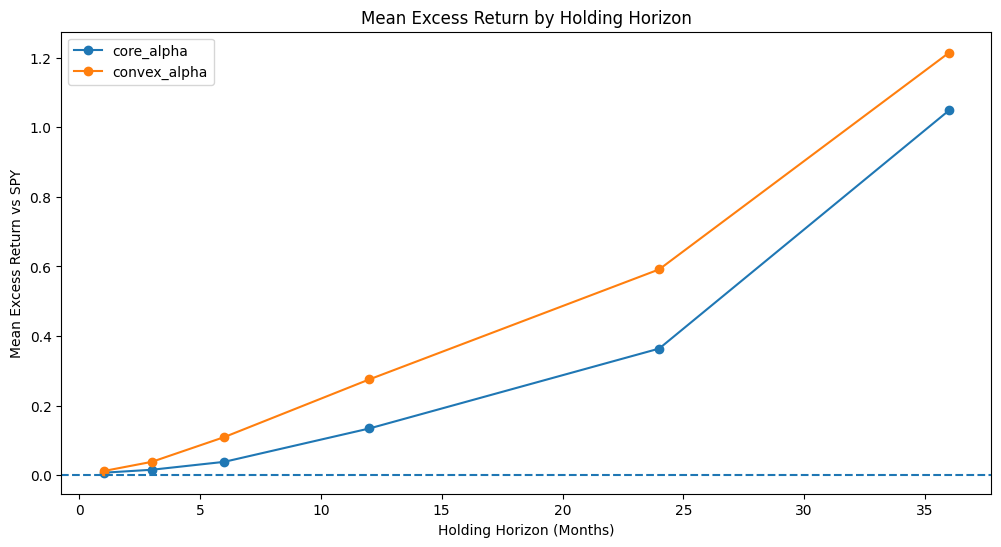

In [12]:
# ======================================
# Alpha Maturation Curve
# ======================================
#
# This shows how excess return develops over time.
#
# Core question:
#   Does the strategy work quickly, slowly, or only over long horizons?

plt.figure(figsize=(12, 6))

for strategy in horizon_summary["strategy"].unique():
    temp = horizon_summary[horizon_summary["strategy"] == strategy]

    plt.plot(
        temp["horizon_months"],
        temp["mean_excess_return"],
        marker="o",
        label=strategy
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Holding Horizon (Months)")
plt.ylabel("Mean Excess Return vs SPY")
plt.title("Mean Excess Return by Holding Horizon")
plt.legend()
plt.show()

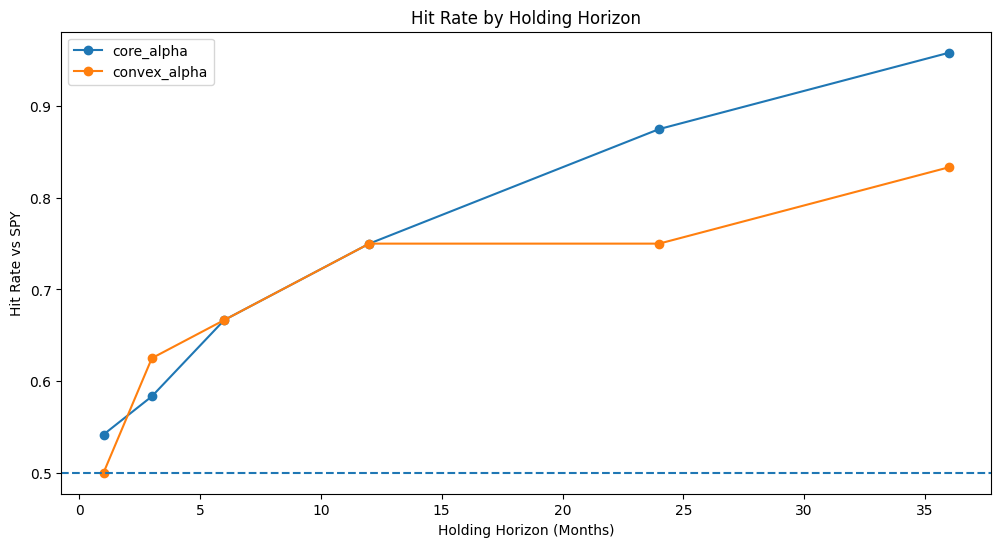

In [13]:
# ======================================
# Hit Rate by Horizon
# ======================================
#
# Hit rate helps distinguish:
#
# 1. Consistent alpha:
#    Many cohorts beat SPY.
#
# 2. Power-law alpha:
#    Mean is high because a few winners dominate.
#
# Convex Alpha may have stronger right-tail behavior.
# Core Alpha should ideally have steadier hit rates.

plt.figure(figsize=(12, 6))

for strategy in horizon_summary["strategy"].unique():
    temp = horizon_summary[horizon_summary["strategy"] == strategy]

    plt.plot(
        temp["horizon_months"],
        temp["hit_rate"],
        marker="o",
        label=strategy
    )

plt.axhline(0.5, linestyle="--")
plt.xlabel("Holding Horizon (Months)")
plt.ylabel("Hit Rate vs SPY")
plt.title("Hit Rate by Holding Horizon")
plt.legend()
plt.show()

In [14]:
# ======================================
# Top-K Candidate Sensitivity
# ======================================
#
# Before finalizing Core Alpha and Convex Alpha defaults,
# test multiple top-k choices.
#
# This answers:
#   - Is top 3 too narrow?
#   - Is top 5 carried by outliers?
#   - Does top 20 provide a better robust core?
#
# We use the same rank-weighting idea but vary the number of selected names.

topk_results = []

for k in [3, 5, 10, 15, 20]:
    p = build_topk_strategy(
        backtest_df,
        strategy_name=f"top_{k}",
        top_k=k,
        power=0.8 if k <= 5 else 0.6,
    )

    s = summarize_by_horizon(p, f"top_{k}")
    topk_results.append(s)

topk_summary = pd.concat(topk_results, ignore_index=True)

topk_summary[
    [
        "strategy",
        "horizon_months",
        "mean_excess_return",
        "median_excess_return",
        "excess_std",
        "hit_rate",
    ]
]

,strategy,horizon_months,mean_excess_return,median_excess_return,excess_std,hit_rate
0,top_3,1,0.012336,0.006490,0.087465,0.500000
1,top_3,3,0.038859,0.036905,0.139831,0.625000
2,top_3,6,0.109975,0.088987,0.235639,0.666667
3,top_3,12,0.275590,0.339396,0.409002,0.750000
4,top_3,24,0.591643,0.525858,0.730011,0.750000
5,top_3,36,1.214124,1.144843,0.975747,0.833333
6,top_5,1,0.008898,0.001377,0.069704,0.500000
7,top_5,3,0.025899,0.033666,0.097064,0.583333
8,top_5,6,0.081126,0.081759,0.186538,0.750000
9,top_5,12,0.263587,0.361258,0.341874,0.791667


In [15]:
# ======================================
# Contributor Analysis
# ======================================
#
# This checks whether a strategy is broadly successful
# or carried by a small number of monster winners.
#
# Especially important for Convex Alpha.

def contributor_analysis(portfolio, horizon=36, top_n=20):
    excess_col = f"fwd_{horizon}m_excess_return"

    valid = portfolio.dropna(subset=[excess_col, "weight"]).copy()

    valid["weighted_excess_contribution"] = (
        valid[excess_col] * valid["weight"]
    )

    contributors = (
        valid.groupby("ticker")["weighted_excess_contribution"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
    )

    return contributors


for name, portfolio in strategy_portfolios.items():
    print(f"\nTop contributors for {name}:")
    display(contributor_analysis(portfolio, horizon=36))


Top contributors for core_alpha:


ticker
PLTR    12.772038
VRT      4.294232
NFLX     2.248273
RCL      1.886530
META     1.821148
VST      1.509967
FANG     0.987441
DASH     0.856132
VLO      0.773781
TPL      0.766743
TRGP     0.606981
AXON     0.599337
NVDA     0.483162
SMCI     0.341953
TPR      0.330265
MPWR     0.256867
BLDR     0.176893
AVGO     0.171672
NOW      0.107328
COP      0.103931
Name: weighted_excess_contribution, dtype: float64


Top contributors for convex_alpha:


ticker
NFLX    10.921211
META     8.950682
PLTR     7.185532
FANG     3.685696
VLO      3.450196
DASH     0.349617
SW      -0.058563
KIM     -0.092317
TSLA    -0.201874
GNRC    -0.293788
DDOG    -0.309949
WBD     -0.435822
DXCM    -0.871464
PSKY    -3.140190
Name: weighted_excess_contribution, dtype: float64

In [16]:
# ======================================
# Contributor Concentration Metrics
# ======================================
#
# This quantifies whether strategy performance is broad-based
# or dependent on a few major winners.
#
# Helpful interpretation:
#   - High top_1_share_of_positive means one name is carrying the strategy.
#   - High top_3/top_5 share means performance is power-law concentrated.
#   - This is not automatically bad for Convex Alpha, but it should be explicit.

def contributor_concentration(portfolio, horizon=36):
    excess_col = f"fwd_{horizon}m_excess_return"

    valid = portfolio.dropna(subset=[excess_col, "weight"]).copy()

    if valid.empty:
        return pd.Series({
            "top_1_contribution": np.nan,
            "top_3_contribution": np.nan,
            "top_5_contribution": np.nan,
            "total_positive_contribution": np.nan,
            "top_1_share_of_positive": np.nan,
            "top_3_share_of_positive": np.nan,
            "top_5_share_of_positive": np.nan,
        })

    valid["weighted_excess_contribution"] = (
        valid[excess_col] * valid["weight"]
    )

    contrib = (
        valid.groupby("ticker")["weighted_excess_contribution"]
        .sum()
        .sort_values(ascending=False)
    )

    total_positive = contrib[contrib > 0].sum()

    top_1 = contrib.iloc[0] if len(contrib) >= 1 else np.nan
    top_3 = contrib.head(3).sum()
    top_5 = contrib.head(5).sum()

    return pd.Series({
        "top_1_contribution": top_1,
        "top_3_contribution": top_3,
        "top_5_contribution": top_5,
        "total_positive_contribution": total_positive,
        "top_1_share_of_positive": top_1 / total_positive if total_positive != 0 else np.nan,
        "top_3_share_of_positive": top_3 / total_positive if total_positive != 0 else np.nan,
        "top_5_share_of_positive": top_5 / total_positive if total_positive != 0 else np.nan,
    })


concentration_summary = pd.DataFrame({
    name: contributor_concentration(portfolio, horizon=36)
    for name, portfolio in strategy_portfolios.items()
}).T

concentration_summary

,top_1_contribution,top_3_contribution,top_5_contribution,total_positive_contribution,top_1_share_of_positive,top_3_share_of_positive,top_5_share_of_positive
core_alpha,12.772038,19.314543,23.022222,31.490462,0.405584,0.613346,0.731086
convex_alpha,10.921211,27.057425,34.193317,34.542935,0.316163,0.783298,0.989879


In [17]:
# ======================================
# Selection Frequency
# ======================================
#
# This shows whether a strategy repeatedly selects the same names.
#
# Repeated selection is not automatically bad.
# But if one or two names appear constantly, performance may be fragile.

def selection_frequency(portfolio, top_n=25):
    return (
        portfolio.groupby("ticker")["cohort_month"]
        .nunique()
        .sort_values(ascending=False)
        .head(top_n)
    )


for name, portfolio in strategy_portfolios.items():
    print(f"\nMost frequently selected tickers for {name}:")
    display(selection_frequency(portfolio))


Most frequently selected tickers for core_alpha:


ticker
NCLH    24
TSLA    24
DDOG    22
FANG    22
PLTR    16
MPWR    16
PSKY    16
ALGN    15
WBD     15
GNRC    14
TPR     14
RCL     14
EQT     14
TTD     13
DASH    13
SW      13
AXON    11
KIM     10
EPAM    10
VLO     10
BIIB     9
VRT      9
AMD      9
NFLX     9
BA       9
Name: cohort_month, dtype: int64


Most frequently selected tickers for convex_alpha:


ticker
DDOG    11
FANG     9
PSKY     8
META     7
NFLX     7
PLTR     7
VLO      7
DASH     5
DXCM     4
KIM      3
GNRC     1
SW       1
TSLA     1
WBD      1
Name: cohort_month, dtype: int64

In [18]:
# ======================================
# Sector Exposure
# ======================================
#
# This shows whether a strategy is implicitly concentrated in specific sectors.
#
# Output is normalized by number of cohorts, so values read as:
#   "average portfolio weight allocated to this sector per cohort"
#
# Example:
#   Technology = 0.25 means the strategy averaged ~25% Technology exposure.

def sector_exposure(portfolio):
    raw = (
        portfolio.groupby("sector")["weight"]
        .sum()
        .sort_values(ascending=False)
    )

    num_cohorts = portfolio["cohort_month"].nunique()

    if num_cohorts == 0:
        return raw * np.nan

    return raw / num_cohorts


for name, portfolio in strategy_portfolios.items():
    print(f"\nAverage sector exposure for {name}:")
    display(sector_exposure(portfolio))


Average sector exposure for core_alpha:


sector
Consumer Cyclical         0.260923
Technology                0.206858
Communication Services    0.158651
Energy                    0.139831
Healthcare                0.071703
Industrials               0.069808
Real Estate               0.042173
Financial Services        0.033115
Utilities                 0.010723
Consumer Defensive        0.006215
Name: weight, dtype: float64


Average sector exposure for convex_alpha:


sector
Communication Services    0.394210
Energy                    0.238616
Technology                0.187029
Consumer Cyclical         0.079432
Healthcare                0.050357
Real Estate               0.036269
Industrials               0.014088
Name: weight, dtype: float64

In [19]:
# ======================================
# Ex-Contributor Stress Test
# ======================================
#
# This checks whether performance survives after removing the biggest winners.
#
# If performance collapses after removing one name,
# the strategy is highly contributor-sensitive.
#
# This is especially important for Convex Alpha.

def run_strategy_with_exclusions(
    df,
    strategy_name,
    top_k,
    power,
    excluded_tickers=None
):
    if excluded_tickers is None:
        excluded_tickers = []

    filtered = df[~df["ticker"].isin(excluded_tickers)].copy()

    p = build_topk_strategy(
        filtered,
        strategy_name=strategy_name,
        top_k=top_k,
        power=power,
    )

    s = summarize_by_horizon(p, strategy_name)
    return s


# Define stress tests based on observed contributors
EXCLUSION_SETS = {
    "none": [],
    "ex_PLTR": ["PLTR"],
    "ex_PLTR_NFLX": ["PLTR", "NFLX"],
    "ex_PLTR_NFLX_META": ["PLTR", "NFLX", "META"],
    "ex_top5": ["PLTR", "NFLX", "META", "FANG", "VLO"],
}

stress_results = []

for label, excluded in EXCLUSION_SETS.items():
    # Core Alpha stress test
    stress_results.append(
        run_strategy_with_exclusions(
            backtest_df,
            strategy_name=f"core_alpha_{label}",
            top_k=STRATEGIES["core_alpha"]["top_k"],
            power=STRATEGIES["core_alpha"]["power"],
            excluded_tickers=excluded,
        )
    )

    # Convex Alpha stress test
    stress_results.append(
        run_strategy_with_exclusions(
            backtest_df,
            strategy_name=f"convex_alpha_{label}",
            top_k=STRATEGIES["convex_alpha"]["top_k"],
            power=STRATEGIES["convex_alpha"]["power"],
            excluded_tickers=excluded,
        )
    )

stress_summary = pd.concat(stress_results, ignore_index=True)

stress_summary[
    [
        "strategy",
        "horizon_months",
        "mean_excess_return",
        "median_excess_return",
        "excess_std",
        "hit_rate",
    ]
]

,strategy,horizon_months,mean_excess_return,median_excess_return,excess_std,hit_rate
0,core_alpha_none,1,0.007548,0.002167,0.052911,0.541667
1,core_alpha_none,3,0.016084,0.009902,0.075473,0.583333
2,core_alpha_none,6,0.038839,0.024996,0.117133,0.666667
3,core_alpha_none,12,0.134633,0.112423,0.198069,0.750000
4,core_alpha_none,24,0.364142,0.138840,0.451864,0.875000
5,core_alpha_none,36,1.048415,0.535759,1.053234,0.958333
6,convex_alpha_none,1,0.012336,0.006490,0.087465,0.500000
7,convex_alpha_none,3,0.038859,0.036905,0.139831,0.625000
8,convex_alpha_none,6,0.109975,0.088987,0.235639,0.666667
9,convex_alpha_none,12,0.275590,0.339396,0.409002,0.750000


In [20]:
# ======================================
# Final Strategy Comparison
# ======================================
#
# Summarize the main horizons that matter for this project.
#
# For Convex Alpha:
#   6m, 12m, 24m, 36m are most relevant.
#
# For Core Alpha:
#   12m, 24m, 36m are most relevant.

main_horizons = [6, 12, 24, 36]

final_comparison = horizon_summary[
    horizon_summary["horizon_months"].isin(main_horizons)
].copy()

final_comparison = final_comparison[
    [
        "strategy",
        "horizon_months",
        "num_cohorts",
        "mean_excess_return",
        "median_excess_return",
        "excess_std",
        "hit_rate",
    ]
].sort_values(["strategy", "horizon_months"])

final_comparison

,strategy,horizon_months,num_cohorts,mean_excess_return,median_excess_return,excess_std,hit_rate
8,convex_alpha,6,24,0.109975,0.088987,0.235639,0.666667
9,convex_alpha,12,24,0.275590,0.339396,0.409002,0.750000
10,convex_alpha,24,24,0.591643,0.525858,0.730011,0.750000
11,convex_alpha,36,24,1.214124,1.144843,0.975747,0.833333
2,core_alpha,6,24,0.038839,0.024996,0.117133,0.666667
3,core_alpha,12,24,0.134633,0.112423,0.198069,0.750000
4,core_alpha,24,24,0.364142,0.138840,0.451864,0.875000
5,core_alpha,36,24,1.048415,0.535759,1.053234,0.958333


In [21]:
# ======================================
# Save Backtest Outputs
# ======================================
#
# Save core outputs for README updates, reports, or future notebooks.

BACKTEST_SUMMARY_FILE = PROCESSED_DIR / "backtest_horizon_summary_04.csv"
TOPK_SUMMARY_FILE = PROCESSED_DIR / "topk_sensitivity_summary_04.csv"
STRESS_SUMMARY_FILE = PROCESSED_DIR / "ex_contributor_stress_summary_04.csv"
CONCENTRATION_SUMMARY_FILE = PROCESSED_DIR / "contributor_concentration_summary_04.csv"

CORE_PORTFOLIO_FILE = PROCESSED_DIR / "portfolio_core_alpha_04.parquet"
CONVEX_PORTFOLIO_FILE = PROCESSED_DIR / "portfolio_convex_alpha_04.parquet"

horizon_summary.to_csv(BACKTEST_SUMMARY_FILE, index=False)
topk_summary.to_csv(TOPK_SUMMARY_FILE, index=False)
stress_summary.to_csv(STRESS_SUMMARY_FILE, index=False)
concentration_summary.to_csv(CONCENTRATION_SUMMARY_FILE)

strategy_portfolios["core_alpha"].to_parquet(CORE_PORTFOLIO_FILE, index=False)
strategy_portfolios["convex_alpha"].to_parquet(CONVEX_PORTFOLIO_FILE, index=False)

print(f"Saved horizon summary to:        {BACKTEST_SUMMARY_FILE}")
print(f"Saved top-k summary to:          {TOPK_SUMMARY_FILE}")
print(f"Saved stress summary to:         {STRESS_SUMMARY_FILE}")
print(f"Saved concentration summary to:  {CONCENTRATION_SUMMARY_FILE}")

print(f"Saved core portfolio to:         {CORE_PORTFOLIO_FILE}")
print(f"Saved convex portfolio to:       {CONVEX_PORTFOLIO_FILE}")

Saved horizon summary to:        /Users/neilyejjey/stock_signal_engine_v1/data/processed/backtest_horizon_summary_04.csv
Saved top-k summary to:          /Users/neilyejjey/stock_signal_engine_v1/data/processed/topk_sensitivity_summary_04.csv
Saved stress summary to:         /Users/neilyejjey/stock_signal_engine_v1/data/processed/ex_contributor_stress_summary_04.csv
Saved concentration summary to:  /Users/neilyejjey/stock_signal_engine_v1/data/processed/contributor_concentration_summary_04.csv
Saved core portfolio to:         /Users/neilyejjey/stock_signal_engine_v1/data/processed/portfolio_core_alpha_04.parquet
Saved convex portfolio to:       /Users/neilyejjey/stock_signal_engine_v1/data/processed/portfolio_convex_alpha_04.parquet


In [22]:
# ======================================
# Top-K Sensitivity: 36M Focus View
# ======================================
#
# The full top-k table is useful, but 36M is the primary target horizon.
# This view makes it easier to compare candidate portfolio sizes.

topk_36m = topk_summary[
    topk_summary["horizon_months"] == 36
][
    [
        "strategy",
        "mean_excess_return",
        "median_excess_return",
        "excess_std",
        "hit_rate",
    ]
].copy()

topk_36m = topk_36m.sort_values(
    "median_excess_return",
    ascending=False
).reset_index(drop=True)

topk_36m

,strategy,mean_excess_return,median_excess_return,excess_std,hit_rate
0,top_3,1.214124,1.144843,0.975747,0.833333
1,top_5,2.404367,0.600040,2.792440,0.916667
2,top_20,1.048415,0.535759,1.053234,0.958333
3,top_10,1.192234,0.342156,1.390532,0.875000
4,top_15,0.961652,0.336128,1.020147,0.916667


In [23]:
!jupyter nbconvert --to html 04_strategy_backtest_and_cohort_analysis.ipynb


[NbConvertApp] Converting notebook 04_strategy_backtest_and_cohort_analysis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 551519 bytes to 04_strategy_backtest_and_cohort_analysis.html


In [24]:
from IPython.display import FileLink

FileLink("04_strategy_backtest_and_cohort_analysis.html")

/Users/neilyejjey/stock_signal_engine_v1/notebooks/04_strategy_backtest_and_cohort_analysis.html

In [25]:
# ======================================
# Ex-Contributor Stress Test: 36M Focus View
# ======================================
#
# This makes contributor sensitivity easier to inspect.
#
# If performance collapses after removing top contributors,
# the strategy is dependent on a small number of right-tail winners.

stress_36m = stress_summary[
    stress_summary["horizon_months"] == 36
][
    [
        "strategy",
        "mean_excess_return",
        "median_excess_return",
        "excess_std",
        "hit_rate",
    ]
].copy()

stress_36m = stress_36m.sort_values(
    ["strategy"]
).reset_index(drop=True)

stress_36m

,strategy,mean_excess_return,median_excess_return,excess_std,hit_rate
0,convex_alpha_ex_PLTR,0.873149,0.958498,1.174259,0.666667
1,convex_alpha_ex_PLTR_NFLX,0.419582,0.606040,0.726381,0.625000
2,convex_alpha_ex_PLTR_NFLX_META,0.032702,-0.154149,0.603969,0.375000
3,convex_alpha_ex_top5,-0.386238,-0.410039,0.317739,0.083333
4,convex_alpha_none,1.214124,1.144843,0.975747,0.833333
5,core_alpha_ex_PLTR,0.550969,0.333539,0.585190,0.916667
6,core_alpha_ex_PLTR_NFLX,0.504209,0.329946,0.527588,0.875000
7,core_alpha_ex_PLTR_NFLX_META,0.436547,0.319770,0.457332,0.875000
8,core_alpha_ex_top5,0.395090,0.158142,0.537490,0.750000
9,core_alpha_none,1.048415,0.535759,1.053234,0.958333
